<a href="https://colab.research.google.com/github/Nirupama-Halder/Google-Colab-practice-notebooks/blob/main/module_12_ML_Practice_SetUntitled16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import SGDRegressor


**1**. **EDA** **(Exploratory Data Analysis)**

In [ ]:
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

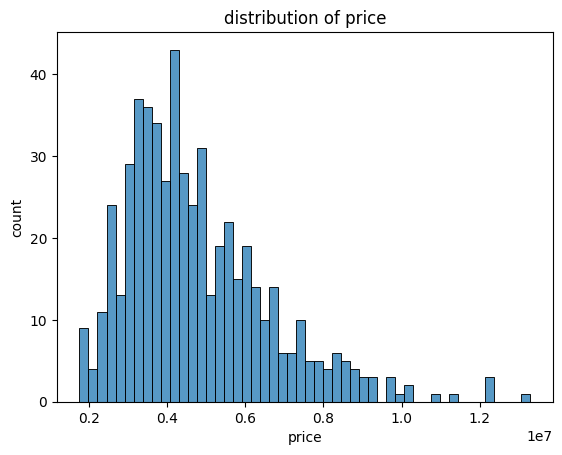

In [ ]:
sns.histplot(df ['price'], bins = 50)
plt.title('distribution of price')
plt.xlabel('price')
plt.ylabel('count')

plt.show()

Price distribution is right-skewed, indicating the presence of some high-value outliers.

Correlation Analysis on numerical columns only

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
corr_matrix


,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


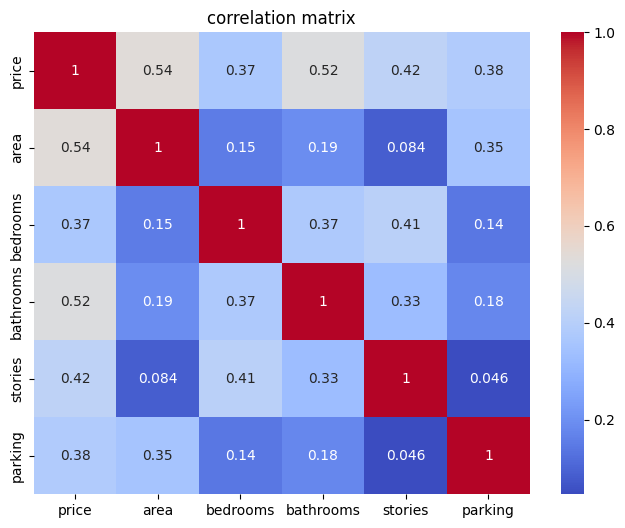

In [ ]:
plt.figure(figsize = (8,6))
sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot = True,
    cmap = 'coolwarm'
)
plt.title('correlation matrix')
plt.show()

Extract correlation with price

In [ ]:
df.select_dtypes(include=[np.number]).corr()['price']

,price
price,1.000000
area,0.535997
bedrooms,0.366494
bathrooms,0.517545
stories,0.420712
parking,0.384394


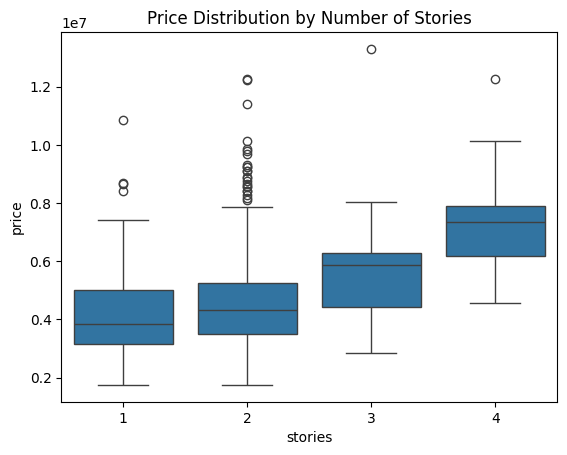

In [ ]:
sns.boxplot(data=df, x = 'stories', y = 'price')
plt.title('Price Distribution by Number of Stories')
plt.show()

In [ ]:
X = df.drop(['price'],axis = 1)
y = df['price']

**2**.**Feature** **Engineering** **via** **Pipeline** & **ColumnTransformer**



In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(f'X_train:{X_train.shape}')
print(f'X_test:{X_test.shape}')
print(f'y_train:{y_train.shape}')
print(f'y_test:{y_test.shape}')

X_train:(436, 12)
X_test:(109, 12)
y_train:(436,)
y_test:(109,)


Numeric columns create

In [ ]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns
print(f'numeric_features:{numeric_features}')


numeric_features:Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


In [ ]:
num_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler())
])
num_transformer


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num',num_transformer,numeric_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))])

In [ ]:
lr_pipeline = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])
lr_pipeline
lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
lr_test_pred = lr_pipeline.predict(X_test)
lr_test_pred

array([6178627.50326817, 6370140.85865473, 3283148.15702491,
       4226007.94816032, 3409685.55116742, 4262158.3499693 ,
       5493440.53152356, 5559897.74293016, 3373715.42245306,
       3020513.186497  , 9519985.014906  , 3250408.25967962,
       3184310.73107686, 3639160.73159381, 3907874.98339005,
       6174323.64572264, 3148160.32926788, 4872535.73454622,
       4826205.69113307, 3888527.39095668, 5222386.81260559,
       4294589.3803585 , 3162381.17719464, 4193028.43115341,
       5747707.28367816, 7619041.42465271, 2989724.54874165,
       4794005.74968624, 7434038.64867546, 3457027.28535552,
       5102872.70577387, 3982998.90101382, 6215707.38061091,
       4724828.08224185, 4307759.63367012, 5625853.70972471,
       4791990.70630181, 3815116.83871034, 3261429.41224535,
       4879463.83866909, 5326652.37523624, 3156512.70502898,
       6345431.50216771, 4316575.21358847, 4120177.60802241,
       4190668.52130486, 6710808.14327266, 4603723.42489655,
       4521704.65093633,

In [ ]:
lr_train_pred = lr_pipeline.predict(X_train)
lr_train_pred

array([ 7048468.97357092,  6609128.69348733,  3889283.61945779,
        3487815.92311087,  3839924.25305077,  4229096.6177212 ,
        3870810.94865954,  3754381.07416122,  3168769.32541906,
        4045951.48070795,  3645338.07071556,  4413601.21630566,
        5361623.58856861,  3784328.200955  ,  3457027.28535552,
        5364495.98552683,  2927853.0996707 ,  5160545.73665557,
        4479600.687055  ,  8428174.7917489 ,  6627660.71085259,
        3608274.03598504,  4782882.1020396 ,  5951477.2594548 ,
        7210624.12551693,  3809037.55744201,  3158057.03980941,
        3422040.22941092,  5317167.02673169,  3777335.28676513,
        3768884.85315062,  2602405.38580775,  3654604.07939819,
        4773698.30859817,  4176954.38149013,  4874808.82903897,
        3249172.79185527,  6187991.56980421,  5818347.07066178,
        6704018.72629249,  7342129.3268503 ,  5572848.14979704,
        4522520.22600445,  3571210.00125453,  4494820.25780998,
        4094191.00520537,  7000265.44858

In [ ]:
X_train_processed = lr_pipeline.named_steps['preprocessor'].transform(X_train)
print(f'X_train_shape:{X_train_processed.shape}')
X_test_processed = lr_pipeline.named_steps['preprocessor'].transform(X_test)
print(f'X_test_shape:{X_test_processed.shape}')

X_train_shape:(436, 5)
X_test_shape:(109, 5)


**3**. **Train** **LinearRegression** & **SGDRegressor** **(using Pipeline)**



In [ ]:
ETA = 0.001
MAX_ITER = 3000
ALPHA = 0.0001
sgd_pipeline = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('model',SGDRegressor(
        loss = 'squared_error',
        penalty = 'l2',
        alpha = ALPHA,
        learning_rate = 'constant',
        eta0 = ETA,
        max_iter = MAX_ITER,
        random_state = 42
    ))
])
sgd_pipeline
sgd_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))])),
                ('model',
                 SGDRegressor(eta0=0.001, learning_rate='constant',
                              max_iter=3000, random_state=42))])

In [ ]:
sgd_pipeline.named_steps['model'].coef_


array([674544.50244428, 112851.3170461 , 561078.06141725, 421790.26113856,
       285271.51364252])

In [ ]:
sgd_pipeline.named_steps['model'].intercept_

array([4702279.35575324])

Generate Prediction for both models on X_train and X_test

In [ ]:
sgd_train_pred = sgd_pipeline.predict(X_train)
sgd_train_pred

array([ 7027662.01746442,  6587085.83865617,  3888563.6905554 ,
        3494167.95793869,  3843421.38940045,  4229438.33996344,
        3874057.65531815,  3757549.61030481,  3176686.00850525,
        4046755.96056788,  3650412.91411895,  4410361.63312647,
        5349163.30506979,  3788276.11074859,  3462565.80015898,
        5355141.90576496,  2937723.13434721,  5153908.44257016,
        4476889.13405236,  8394334.18921849,  6605467.59820678,
        3613649.39501771,  4779755.91037139,  5936122.38024572,
        7188502.41353234,  3812785.12348275,  3164997.42357205,
        3427903.38903038,  5305402.01710113,  3779254.55522189,
        3772957.97778974,  2613850.99971266,  3659603.79389426,
        4768758.63444818,  4177875.29942187,  4866964.00963342,
        3255374.40802926,  6172117.00399012,  5804603.82731099,
        6684491.14616632,  7317960.15319651,  5559343.6193734 ,
        4520482.86618157,  3576885.87591648,  4491944.33499364,
        4094760.78425882,  6979514.50767

In [ ]:
sgd_test_pred = sgd_pipeline.predict(X_test)
sgd_test_pred

array([6163892.01607682, 6354677.36905244, 3289074.30053872,
       4226374.71337167, 3415648.8826633 , 4261209.82199176,
       5480777.23418264, 5551044.68338961, 3378041.4860333 ,
       3029631.9321003 , 9479868.5875869 , 3256599.85866596,
       3191038.24960209, 3644285.66093541, 3910821.17441938,
       6159957.87380117, 3156203.140982  , 4866794.68538481,
       4820840.28650826, 3889545.11252561, 5216719.29688385,
       4293377.90120535, 3169286.50080052, 4192796.83519546,
       5732116.62904102, 7590698.13031279, 2998029.77432059,
       4790299.39676869, 7406663.14429523, 3462565.80015898,
       5096662.05594567, 3984470.22695511, 6201496.03946395,
       4721150.4079425 , 4308526.70991558, 5614536.96428802,
       4786036.95769534, 3819878.2685283 , 3268594.80625835,
       4876127.74522273, 5315341.39822707, 3163465.61027616,
       6330168.35631828, 4315341.89886625, 4119317.10690834,
       4188370.71955641, 6693604.70462826, 4601225.06376285,
       4517588.56383842,

**4**. **Evaluation** **Metrics** — **RMSE**, **MAE**, **R²**


In [ ]:
def evaluate (model , name):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)



  Train_RMSE = round(np.sqrt(mean_squared_error(y_train,train_pred)),4)
  Test_RMSE = round(np.sqrt(mean_squared_error(y_test,test_pred)),4)
  Train_MAE = round(mean_absolute_error(y_train,train_pred),4)
  Test_MAE = round(mean_absolute_error(y_test,test_pred),4)
  Train_R2 = round(r2_score(y_train,train_pred),4)
  Test_R2 = round(r2_score(y_test,test_pred),4)
  print(f'model_name:{name}')
  print(f'{"-"*40}')
  print(f'Train_RMSE:{Train_RMSE}')
  print(f'Test_RMSE:{Test_RMSE}')
  print(f'Train_MAE:{Train_MAE}')
  print(f'Test_MAE:{Test_MAE}')
  print(f'Train_R2:{Train_R2}')
  print(f'Test_R2:{Test_R2}')


  return(
      Train_RMSE,
      Test_RMSE,
      Train_MAE,
      Test_MAE,
      Train_R2,
      Test_R2,
      name

  )



In [ ]:
lr_Train_R2,lr_Train_RMSE,lr_Train_MAE,lr_Test_R2,lr_Test_RMSE,lr_Test_MAE,lr_model_name = evaluate(
    lr_pipeline,
    'LinearRegression'
    )

model_name:LinearRegression
----------------------------------------
Train_RMSE:1161898.5374
Test_RMSE:1514173.552
Train_MAE:853544.1615
Test_MAE:1127483.3523
Train_R2:0.5622
Test_R2:0.5464


In [ ]:
sgd_Train_R2,sgd_Train_RMSE,sgd_Train_MAE,sgd_Test_R2,sgd_Test_RMSE,sgd_Test_MAE,sgd_model_name = evaluate(
    sgd_pipeline,
    'SGDRegression'
    )

model_name:SGDRegression
----------------------------------------
Train_RMSE:1161950.2561
Test_RMSE:1516719.4618
Train_MAE:852981.0303
Test_MAE:1128789.4933
Train_R2:0.5621
Test_R2:0.5449


In [ ]:
results = {
    'Model': [lr_model_name, sgd_model_name],
    'Train_RMSE': [lr_Train_RMSE, sgd_Train_RMSE],
    'Test_RMSE': [lr_Test_RMSE, sgd_Test_RMSE],
    'Train_MAE': [lr_Train_MAE, sgd_Train_MAE],
    'Test_MAE': [lr_Test_MAE, sgd_Test_MAE],
    'Train_R2': [lr_Train_R2, sgd_Train_R2],
    'Test_R2': [lr_Test_R2, sgd_Test_R2]
}

In [ ]:
results_df = pd.DataFrame(results)
print(results_df)

              Model    Train_RMSE  Test_RMSE    Train_MAE  Test_MAE  \
0  LinearRegression  1.514174e+06     0.5622  853544.1615    0.5464   
1     SGDRegression  1.516719e+06     0.5621  852981.0303    0.5449   

       Train_R2       Test_R2  
0  1.161899e+06  1.127483e+06  
1  1.161950e+06  1.128789e+06  


**5**. **Which** **model** **has** **lower** **Test** **RMSE** — **LinearRegression** **or** **SGDRegressor**?



LinearRegression has a lower Test RMSE (1,514,173.55) than SGDRegressor (1,516,719.46). Therefore, LinearRegression performs slightly better on the test data.

 **Is** **Train** **R²** **much** **higher** **than** **Test** **R²**?


No, Train R² is not much higher than Test R² for either model. The difference between Train R² and Test R² is very small, indicating that the models are not significantly overfitting and generalize reasonably well to unseen data.



 **Learn** **about** **Overfitting** **and** **Underfitting**


 Overfitting occurs when a model learns the training data too well, including noise and patterns that do not generalize to new data. In such cases, the model achieves very high performance on the training set but performs much worse on the test set. Since the Train R² and Test R² values are close in this case, there is no strong evidence of overfitting.